In [1]:
import os
import yaml
import warnings
warnings.filterwarnings("ignore")

# Basic Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tensorflow Packages
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (Dense, 
                               Input, 
                               Conv2D, 
                               Conv2DTranspose,
                               Flatten,
                               Lambda,
                               Reshape)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (EarlyStopping, 
                                        ModelCheckpoint)
from tensorflow.keras.optimizers import Adam


# Image Dataset

In [27]:
# filepaths
train_image_dir = "/Users/kavisanthoshkumar/Downloads/BSR/BSDS500/data/images/train" 
valid_image_dir = "/Users/kavisanthoshkumar/Downloads/BSR/BSDS500/data/images/val"
test_image_dir = "/Users/kavisanthoshkumar/Downloads/BSR/BSDS500/data/images/test"

# Load filepath for train, val, test directory
train_image_path = [os.path.join(train_image_dir, fname) for fname in os.listdir(train_image_dir)]
val_image_path = [os.path.join(valid_image_dir, fname) for fname in os.listdir(valid_image_dir)]
test_image_path = [os.path.join(test_image_dir, fname) for fname in os.listdir(test_image_dir)]

# Create dataset for image paths
train_path_ds = tf.data.Dataset.from_tensor_slices(train_image_path)
val_path_ds = tf.data.Dataset.from_tensor_slices(val_image_path)
test_path_ds = tf.data.Dataset.from_tensor_slices(test_image_path)

In [28]:
img_height = 64
img_width = 64
batch_size = 32

def load_and_preprocess_image(path: str) -> [tf.Tensor,tf.Tensor]:
    """
        Loading and Preprocessing Image using Tensorflow

        Args
            path (str) : Image filepath

        Returns
            input (tf.Tensor) - Input Image
            output (tf.Tensor) - Output Image
    
    """
    img = tf.io.read_file(path) # Read the contents of the file
    img = tf.image.decode_jpeg(img, channels = 3) 
    img = tf.image.resize(img, [img_height, img_width])
    img = tf.cast(img, tf.float32) / 255.0 # Normalize
    
    return img, img # Both Input and Target are Images because we are performing Variational Autoencoder


train_img_dataset = (train_path_ds.map(lambda x : load_and_preprocess_image(x), num_parallel_calls= tf.data.AUTOTUNE) 
                                 .shuffle(1000) 
                                 .batch(batch_size) 
                                 .prefetch(tf.data.AUTOTUNE))

val_img_dataset = (val_path_ds.map(lambda x : load_and_preprocess_image(x), num_parallel_calls=tf.data.AUTOTUNE) 
                                 .shuffle(1000) 
                                 .batch(batch_size) 
                                 .prefetch(tf.data.AUTOTUNE))
test_img_dataset = (test_path_ds.map(lambda x : load_and_preprocess_image(x), num_parallel_calls=tf.data.AUTOTUNE) 
                                 .shuffle(1000) 
                                 .batch(batch_size) 
                                 .prefetch(tf.data.AUTOTUNE))

#### Step 1: Loading train, valid, test images from the local directory

In [15]:
img_size = (64, 64)
batch_size = 32

# Train Image Dataset
train_img_dataset = tf.keras.utils.image_dataset_from_directory(
    directory = "/Users/kavisanthoshkumar/Downloads/BSR/BSDS500/data/images/train",
    labels = None,
    class_names = None, 
    color_mode = "rgb",
    image_size = img_size, 
    shuffle = False, 
    seed = 42,
    verbose = True,
    batch_size = batch_size
)

# Valid Image Dataset
valid_img_dataset = tf.keras.utils.image_dataset_from_directory(
    directory = "/Users/kavisanthoshkumar/Downloads/BSR/BSDS500/data/images/val",
    labels = None, 
    class_names = None, 
    color_mode = "rgb",
    image_size = img_size,
    shuffle = True,
    seed = 42, 
    verbose = True,
    batch_size = batch_size
)


# Test Image Dataset
test_img_dataset = tf.keras.utils.image_dataset_from_directory(
    directory = "/Users/kavisanthoshkumar/Downloads/BSR/BSDS500/data/images/test",
    labels = None, 
    class_names = None, 
    color_mode = "rgb",
    image_size = img_size,
    shuffle = True,
    seed = 42, 
    verbose = True,
    batch_size = batch_size
)


Found 200 files.
Found 100 files.
Found 200 files.


In [70]:
# Normalize using a layer
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_img_dataset = train_img_dataset.map(lambda x, y: (normalization_layer(x), normalization_layer(y)))
val_img_dataset = val_img_dataset.map(lambda x, y: (normalization_layer(x), normalization_layer(y)))
test_img_dataset = test_img_dataset.map(lambda x, y: (normalization_layer(x), normalization_layer(y)))


#### Step 2: View Train Sample Normalized Images

In [5]:
(train_img, train_img) = next(iter(train_img_dataset.take(1)))
images, _  = sample_batch

plt.figure(figsize= (10, 10))
for i in range(16):
    ax = plt.subplot(4, 4, i+1)
    plt.imshow(images[i].numpy())
    plt.axis("off")



2025-06-13 16:49:26.692429: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: INVALID_ARGUMENT: Error in user-defined function passed to ParallelMapDatasetV2:3 transformation with iterator: Iterator::Root::Prefetch::FiniteTake::Prefetch::BatchV2::Shuffle::ParallelMapV2: Unknown image file format. One of JPEG, PNG, GIF, BMP required.
	 [[{{node DecodeJpeg}}]]


InvalidArgumentError: {{function_node __wrapped__IteratorGetNext_output_types_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} Error in user-defined function passed to ParallelMapDatasetV2:3 transformation with iterator: Iterator::Root::Prefetch::FiniteTake::Prefetch::BatchV2::Shuffle::ParallelMapV2: Unknown image file format. One of JPEG, PNG, GIF, BMP required.
	 [[{{node DecodeJpeg}}]] [Op:IteratorGetNext] name: 

#### Step 3: Adding Noise to the Images

In [29]:
def add_noise(image):
    """
        Adds noise to an image

        Args:
            image (numpy.ndarray) : The input image.

        Returns:
            numpy.ndarray: The image with noise added.
    """
    noise = np.random.normal(0, 0.1, image.shape)
    noisy_image = tf.clip_by_value(noise + image, 0, 1)
    return noisy_image

In [30]:
# Since each batch is a tensor of shape (batch_size, height, weight, channels),
# map_fn is used inside the .map() to apply preprocess_image to each image in the batch
train_img_dataset = train_img_dataset.map(
    lambda batch_x, batch_y : (tf.map_fn(add_noise, batch_x), batch_y)
)

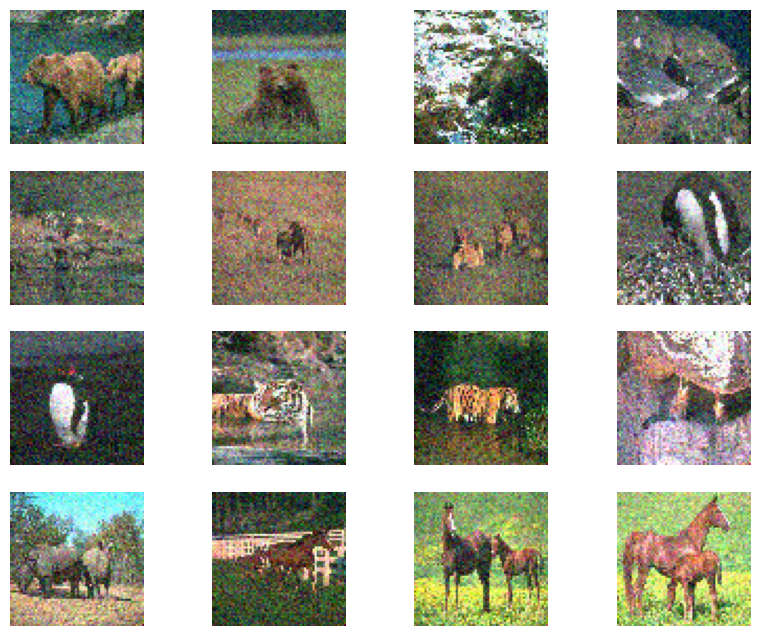

In [20]:
sample_batch = train_img_dataset.take(1)
for image in sample_batch:
    plt.figure(figsize = (10, 8))
    for i in range(16):
        ax = plt.subplot(4, 4, i+1)
        plt.imshow(image[i])
        plt.axis("off")
    break


- Observation : We have added the noise to the training image dataset

### Convolutional Variational Autoencoder (CVAEs)

- As we know, Autoencoders used to have three layers Encoder, bottleneck or latent space representation and Decoder or output layer. In case of Convolutional Variational AutoEncoders (C VAEs) we have, the encoder and decoder has two-dimensional convolutional layers with variational layer length. 

#### Architecture

In [48]:
IMG_HEIGHT = 64
IMG_WIDHT = 64
IMG_CHANNEL = 3

IMG_SHAPE = (IMG_HEIGHT, IMG_WIDHT, IMG_CHANNEL)

LATENT_DIM = 2

##### 1. Encoder

In [49]:
encoder_input = Input(shape = IMG_SHAPE)

# Convolution layer 1
conv_1 = Conv2D(filters = 32, 
                kernel_size = 3,
                padding = "same", 
                activation = "relu",
                data_format = 'channels_last')(encoder_input)

# Convolution layer 2
conv_2 = Conv2D(filters = 64,
                kernel_size = 3,
                padding = "same", 
                activation = "relu",
                data_format = 'channels_last')(conv_1)

# Convolution layer 3
conv_3 = Conv2D(filters = 64, 
                kernel_size = 3, 
                padding = "same",
                activation = "relu",
                data_format = 'channels_last')(conv_2)


# Flatten the data
flatten = Flatten()(conv_3)

# Dense layer 1 
encoder_output = Dense(128, activation = "relu")(flatten)

# latent vector of "mu"
z_mu = Dense(LATENT_DIM)(encoder_output)

# latent vector of "sigma"
z_sigma = Dense(LATENT_DIM)(encoder_output)

# 

##### 2. Latent Variable

In VAEs, for each latent attribute of training data, VAEs encode two different latent vectors: a vector of means "mu" and a vector of standard deviation "sigma". In essence, these two vectors represents range of possibilities for each latent variable and the expected variance within each range of possibility. What differentiate from Basic AutoEncoder to Variational AutoEncoders is probability distribution


To perform this sort of operation, we will be using "Custom Operation with Lambda"

from tensorflow.keras.layers import Lambda 

- Example : cosine similarity

    cos_sim = Lambda(lambda x : tf.keras.losses.cosine_similarity(x[0], x[1]))[dense1, dense2]


In [50]:
# sampling function for latent layer
def sampling(z_mu, z_sigma):
    z_mu, z_sigma = z_mu, z_sigma

    batch = tf.shape(z_mu)[0]
    dim = tf.shape(z_mu)[1]

    # epsilon in simple normal distribution
    epsilon = tf.random.normal(shape = (batch, dim))

    return z_mu + tf.exp(0.5 * z_sigma) * epsilon

# VAEs latent sampling
latent_variables = Lambda(lambda x : sampling(x[0], x[1]))([z_mu, z_sigma])


##### 3. Decoder 

In [51]:
# Dense layer 1
dense_decoder_layer_1 = Dense(8*8*32, activation = 'relu')(latent_variables)
dense_decoder_reshape = Reshape((8,8,32))(dense_decoder_layer_1)

# Conv2D Transpose layer 1
dense_conv2d_layer1 = Conv2DTranspose(filters = 64, 
                                      kernel_size = 3, 
                                      strides = 2,
                                      padding = "same",
                                      activation = "relu"
                                      )(dense_decoder_reshape)

# Input shape = (8, 8, 32)
# Output shape = (16, 16, 64)
    # strides = 2 -> doubles the height and width from 8 to 16
    # filters = 64 -> number of output channel

# Conv2D Transpose layer 2
dense_conv2d_layer2 = Conv2DTranspose(filters = 32, 
                                      kernel_size = 3, 
                                      strides = 2, 
                                      padding = "same",
                                      activation = "relu")(dense_conv2d_layer1)

# Input shape = (16, 16, 64)
# Output shape = (32, 32, 32)
    # strides = 2 -> doubles the height and width from 16 to 32
    # filters = 32 -> number of output channel

# Final Output layer
decoder_output = Conv2DTranspose(filters = 3, 
                                 kernel_size = 3, 
                                 strides = 2, 
                                 padding = "same", 
                                 activation = "sigmoid")(dense_conv2d_layer2)


# Input shape = (32, 32, 32)
# Output shape = (64, 64, 3)
    # strides = 2 -> doubles the height and width from 32 to 64
    # filters = 3 -> number of output channel


In [52]:
conv_autoencoder = Model(inputs = [encoder_input], outputs = [decoder_output])
conv_autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │     18,496 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_7[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 262144)    │          0 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │ 33,554,560 │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 2)         │        258 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 2)         │        258 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 2)         │          0 │ dense_9[0][0],    │
│                     │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 2048)      │      6,144 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 8, 8, 32)  │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 16, 16,    │     18,496 │ reshape_2[0][0]   │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_7  │ (None, 32, 32,    │     18,464 │ conv2d_transpose… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 64, 64, 3) │        867 │ conv2d_transpose… │
│ (Conv2DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,655,367 (128.39 MB)

 Trainable params: 33,655,367 (128.39 MB)

 Non-trainable params: 0 (0.00 B)

#### Optimizer


Generally, VAE models not used to be evaluated on tradition loss functions. Most of the time there are custom and complex loss functions. However, here will use a simple custom loss function by incorporating reconstruction loss and KL loss.

- We are using binary cross entropy as the reconstruction loss.
- keras.metrics.binary_crossentropy is applied to the flatten input data x and the flattened reconstructed output z_decoded.
- KL Divergence Loss calculate how probability distribution diverges from a second.
- The formula used in the code involves mean and log-variance of the latent distribution.
- The total loss is the sum of the reconstructed loss and the KL divergence loss.

In [53]:
def vae_loss(x, z_decoded):
    x = Flatten(x)
    z_decoded = Flatten(z_decoded)

    # Reconstruction loss
    Reconstruction_loss = 786*tf.keras.metrics.binary_crossentropy(x, z_decoded)

    # KL divergence
    kl_loss = -0.5 * tf.mean(1 + z_sigma -
                            tf.square(z_mu) - tf.exp(z_sigma), axis=-1)
    return Reconstruction_loss + kl_loss

#### Compiler

In [54]:
conv_autoencoder.compile(loss = vae_loss, 
                         optimizer = Adam())

#### Callbacks

In [55]:
# ModelCheckpoint Callback
model_filepath = "./artifacts/conv_var_autoencoder.weights.h5"

model_checkpoint_callback = ModelCheckpoint(
    filepath = model_filepath, 
    monitor = "val_loss",
    verbose = 1,
    save_best_only = True,
    save_weights_only = True, 
)

# EarlyStopping Callback
early_stopping_callback = EarlyStopping(
    monitor = "val_loss",
    min_delta = 0, 
    patience = 5, 
    verbose = 1, 
    mode = "auto",
    restore_best_weights = True
)

callbacks = [model_checkpoint_callback, early_stopping_callback]

In [56]:
conv_autoencoder.fit(
    train_img_dataset,
    validation_data=val_img_dataset,
    epochs=10,
    callbacks=callbacks,
)

Epoch 1/10


ValueError: The `data_format` argument must be one of {'channels_first', 'channels_last'}. Received: data_format=tensor("data_1:0", shape=(none, 64, 64, 3), dtype=float32)